In [21]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from src.datasources import glofas, grrr
from src.constants import STATE_CONFIG
from src.utils.rp_calc import calculate_one_group_rp

STATE = "Benue"
cfg = STATE_CONFIG[STATE]

ANALYSIS_START_YEAR = cfg["analysis_start_year"]
ANALYSIS_END_YEAR = cfg["analysis_end_year"]

## Load data

In [22]:
# load glofas reanalysis
df_ra = glofas.load_glofas_reanalysis(station_name=cfg["glofas_station"])

# load glofas reforecast ensemble
df_ref_ens = stratus.load_parquet_from_blob(cfg["glofas_reforecast_blob"])

# load google reanalysis
ds_grrr_ra = grrr.load_reanalysis(gauge=cfg["google_gauge"])
df_grrr_ra = grrr.process_reanalysis(ds_grrr_ra)

# load google reforecast
ds_grrr_rf = grrr.load_reforecast(cfg["google_gauge"])
df_grrr_rf = grrr.process_reforecast(ds_grrr_rf)

# load floodscan pixels
df_fs_pixels = stratus.load_parquet_from_blob(cfg["floodscan_blob"])

/Users/hannahker/Desktop/AA/ds-aa-nga-flooding/src/datasources/grrr.py:22: FutureWarning: In a future version, xarray will not decode the variable 'lead_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  return xr.open_zarr(


## Floodscan Return Periods

In [23]:
df_daily_avg = (
    df_fs_pixels.groupby("date")["SFED"]
    .mean()
    .reset_index()
    .rename(columns={"SFED": "mean"})
)
df_daily_avg["date"] = pd.to_datetime(df_daily_avg["date"])
df_daily_avg = df_daily_avg[
    df_daily_avg["date"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
]

In [24]:
df_annual_max = (
    df_daily_avg.assign(year=df_daily_avg["date"].dt.year)
    .groupby("year")["mean"]
    .max()
    .reset_index()
)

df_annual_rp = calculate_one_group_rp(df_annual_max, col_name="mean", ascending=False)

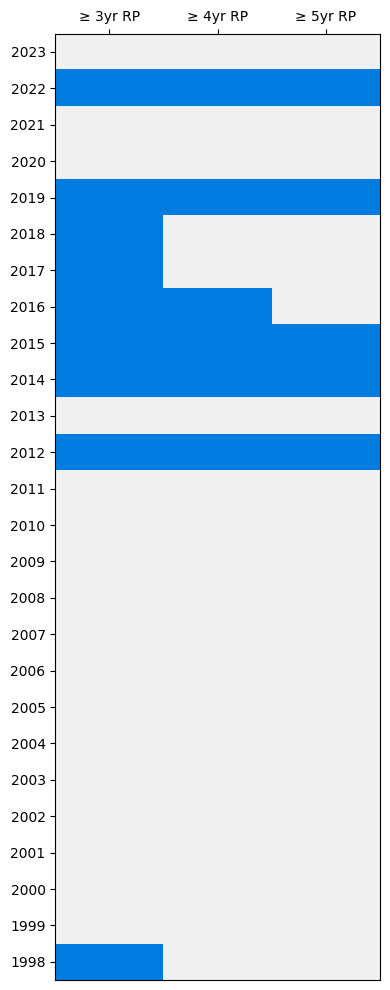

In [25]:
rp_thresholds = [3, 4, 5]

heatmap_matrix = pd.DataFrame(
    {
        f"{rp}yr": (df_annual_rp["mean_rp"] >= rp).astype(int).values
        for rp in rp_thresholds
    },
    index=df_annual_rp["year"].values,
).sort_index(ascending=False)

cmap = mcolors.ListedColormap(["#F0F0F0", "#007CE0"])

fig, ax = plt.subplots(figsize=(4, 10))
ax.imshow(heatmap_matrix.values, cmap=cmap, vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(rp_thresholds)))
ax.set_xticklabels([f"≥ {rp}yr RP" for rp in rp_thresholds])
ax.set_yticks(range(len(heatmap_matrix)))
ax.set_yticklabels(heatmap_matrix.index)
ax.xaxis.tick_top()

plt.tight_layout()
plt.savefig(f"figures/floodscan_only_events_{STATE.lower()}.png", dpi=300, bbox_inches="tight")
plt.show()

## GloFAS and Google Trigger Years

In [16]:
GLOFAS_THRESH = cfg["glofas_thresh"]
GOOGLE_THRESH = cfg["google_thresh"]

# --- Floodscan flood years ---
df_fs_trig = pd.DataFrame(
    {
        f"fs_{rp}yr": (df_annual_rp.set_index("year")["mean_rp"] >= rp).astype(int)
        for rp in [3, 4, 5]
    }
)

# --- Reanalysis triggers ---
df_gf_ra_trig = (
    df_ra.rename(columns={"time": "valid_time"})
    .assign(year=lambda x: pd.to_datetime(x["valid_time"]).dt.year)
    .groupby("year")["dis24"]
    .max()
    .gt(GLOFAS_THRESH)
    .astype(int)
    .rename("glofas_ra")
)

df_grrr_ra_trig = (
    df_grrr_ra
    .assign(year=lambda x: pd.to_datetime(x["valid_time"]).dt.year)
    .groupby("year")["streamflow"]
    .max()
    .gt(GOOGLE_THRESH)
    .astype(int)
    .rename("google_ra")
)

# --- Reforecast triggers ---
# Ensemble mean per (year, issue_time, valid_time, leadtime) — computed once, reused for all lt caps
df_gf_ens_mean = (
    df_ref_ens
    .assign(year=lambda x: pd.to_datetime(x["valid_time"]).dt.year)
    .groupby(["year", "time", "valid_time", "leadtime"])["dis24"]
    .mean()
    .reset_index()
)

gf_trig = {
    f"glofas_{lt}d": (
        df_gf_ens_mean[df_gf_ens_mean["leadtime"] <= lt]
        .groupby("year")["dis24"]
        .max()
        .gt(GLOFAS_THRESH)
        .astype(int)
    )
    for lt in range(5, 15)
}
df_gf_trig = pd.DataFrame(gf_trig)

# Only include years where Google reforecast covers through October (flood season complete)
_grrr_rf_complete_years = (
    df_grrr_rf
    .assign(year=lambda x: pd.to_datetime(x["valid_time"]).dt.year,
            month=lambda x: pd.to_datetime(x["valid_time"]).dt.month)
    .groupby("year")["month"]
    .max()
    .pipe(lambda s: s[s >= 10].index)
)
df_grrr_trig = (
    df_grrr_rf[df_grrr_rf["valid_time"].dt.year.isin(_grrr_rf_complete_years)]
    .assign(year=lambda x: pd.to_datetime(x["valid_time"]).dt.year)
    .groupby("year")["streamflow"]
    .max()
    .gt(GOOGLE_THRESH)
    .astype(int)
    .rename("google")
)

years = list(range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1))
trig_matrix = (
    pd.DataFrame(index=years)
    .join(df_fs_trig, how="left")
    .join(df_gf_ra_trig, how="left")
    .join(df_gf_trig, how="left")
    .join(df_grrr_ra_trig, how="left")
    .join(df_grrr_trig, how="left")
    .rename_axis("year")
    .sort_index(ascending=False)
)

In [17]:
trigger_matrix_blob = f"ds-aa-nga-flooding/processed/trigger_matrix/{STATE.lower()}_trigger_matrix.parquet"
stratus.upload_parquet_to_blob(
    trig_matrix.reset_index(),
    trigger_matrix_blob,
)
print(f"Saved trigger matrix ({trig_matrix.shape[0]} years × {trig_matrix.shape[1]} columns) to: {trigger_matrix_blob}")
print(trig_matrix.reset_index().dtypes)

Saved trigger matrix (26 years × 16 columns) to: ds-aa-nga-flooding/processed/trigger_matrix/adamawa_trigger_matrix.parquet
year            int64
fs_3yr          int64
fs_4yr          int64
fs_5yr          int64
glofas_ra       int64
glofas_5d     float64
glofas_6d     float64
glofas_7d     float64
glofas_8d     float64
glofas_9d     float64
glofas_10d    float64
glofas_11d    float64
glofas_12d    float64
glofas_13d    float64
glofas_14d    float64
google_ra       int64
google        float64
dtype: object


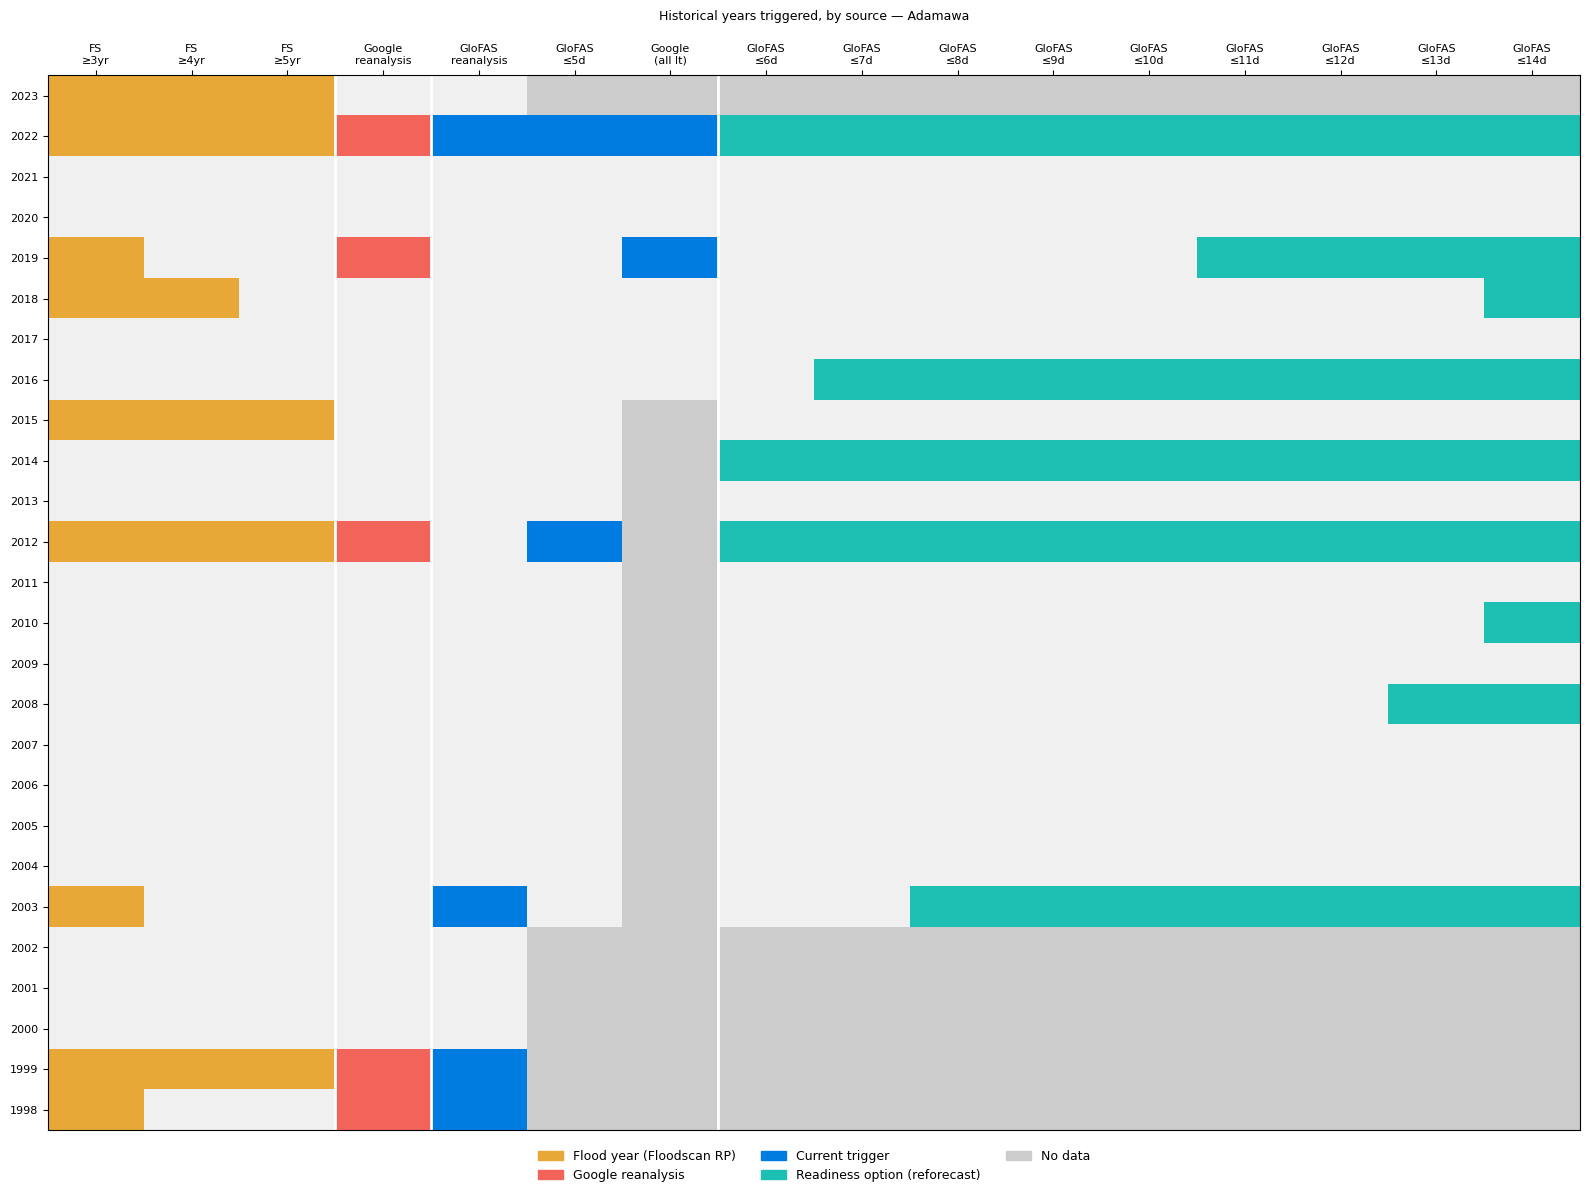

In [18]:
flood_cols = ["fs_3yr", "fs_4yr", "fs_5yr"]
reanalysis_cols = ["google_ra"]
action_cols = ["glofas_ra", "glofas_5d", "google"]
readiness_cols = [f"glofas_{lt}d" for lt in range(6, 15)]

# Groups: flood years | reanalysis | current triggers | readiness options
col_order = flood_cols + reanalysis_cols + action_cols + readiness_cols
col_labels = (
    ["FS\n≥3yr", "FS\n≥4yr", "FS\n≥5yr"]
    + ["Google\nreanalysis"]
    + ["GloFAS\nreanalysis", "GloFAS\n≤5d", "Google\n(all lt)"]
    + [f"GloFAS\n≤{lt}d" for lt in range(6, 15)]
)

# Recode: NaN=0, not triggered=1, action=2, readiness=3, reanalysis=4, flood year=5
plot_data = trig_matrix[col_order].copy()
for col in action_cols:
    plot_data[col] = plot_data[col].map({0.0: 1, 1.0: 2}).fillna(0).astype(int)
for col in readiness_cols:
    plot_data[col] = plot_data[col].map({0.0: 1, 1.0: 3}).fillna(0).astype(int)
for col in reanalysis_cols:
    plot_data[col] = plot_data[col].map({0.0: 1, 1.0: 4}).fillna(0).astype(int)
for col in flood_cols:
    plot_data[col] = plot_data[col].map({0.0: 1, 1.0: 5}).fillna(0).astype(int)

# 0=no data, 1=not triggered, 2=current trigger, 3=readiness, 4=reanalysis, 5=flood year
cmap = mcolors.ListedColormap(["#CCCCCC", "#F0F0F0", "#007CE0", "#1EBFB3", "#F2645A", "#E8A838"])
norm = mcolors.BoundaryNorm([0, 1, 2, 3, 4, 5, 6], cmap.N)

fig, ax = plt.subplots(figsize=(16, 12))
ax.imshow(plot_data.values, cmap=cmap, norm=norm, aspect="auto")

ax.set_xticks(range(len(col_order)))
ax.set_xticklabels(col_labels, fontsize=8)
ax.set_yticks(range(len(trig_matrix)))
ax.set_yticklabels(trig_matrix.index, fontsize=8)
ax.xaxis.tick_top()
ax.set_title(f"Historical years triggered, by source — {STATE}", fontsize=9, pad=40)

# Separators between groups: flood | reanalysis | current triggers | readiness
for x in [2.5, 3.5, 6.5]:
    ax.axvline(x=x, color="white", linewidth=2)

# Legend
legend_items = [
    mpatches.Patch(color="#E8A838", label="Flood year (Floodscan RP)"),
    mpatches.Patch(color="#F2645A", label="Google reanalysis"),
    mpatches.Patch(color="#007CE0", label="Current trigger"),
    mpatches.Patch(color="#1EBFB3", label="Readiness option (reforecast)"),
    mpatches.Patch(color="#CCCCCC", label="No data"),
]
ax.legend(handles=legend_items, loc="lower center", bbox_to_anchor=(0.5, -0.06),
          ncol=3, frameon=False, fontsize=9)

plt.subplots_adjust(bottom=0.1)
plt.tight_layout()
plt.show()

In [19]:
# Trigger rate and false positives for each GloFAS option
# False positive = triggers but is NOT a Floodscan flood year at a given RP threshold
# Only count years where reforecast data exists (non-NaN)

gf_cols = [f"glofas_{lt}d" for lt in range(5, 15)]
baseline = trig_matrix["glofas_5d"]

rows = []
for col in gf_cols:
    valid = trig_matrix[col].notna()
    valid_both = valid & baseline.notna()

    col_data = trig_matrix.loc[valid, col]
    n_years = valid.sum()
    n_triggered = int(col_data.sum())
    rp = round(n_years / n_triggered, 1) if n_triggered > 0 else float("inf")

    col_both = trig_matrix.loc[valid_both, col]
    base_both = baseline[valid_both]
    n_new = int(((col_both == 1) & (base_both == 0)).sum())

    fp = {}
    for rp_thresh in [3, 4, 5]:
        fs_col = trig_matrix.loc[valid, f"fs_{rp_thresh}yr"].fillna(0)
        n_fp = int(((col_data == 1) & (fs_col == 0)).sum())
        fp[f"fp_fs{rp_thresh}yr"] = n_fp
        fp[f"fpr_fs{rp_thresh}yr"] = round(n_fp / n_triggered, 2) if n_triggered > 0 else float("nan")

    rows.append({
        "leadtime_cap": col,
        "n_triggered": n_triggered,
        "implied_rp": rp,
        "n_new_triggers": n_new,
        **fp,
    })

pd.DataFrame(rows)

,leadtime_cap,n_triggered,implied_rp,n_new_triggers,fp_fs3yr,fpr_fs3yr,fp_fs4yr,fpr_fs4yr,fp_fs5yr,fpr_fs5yr
0,glofas_5d,2,10.0,0,0,0.00,0,0.00,0,0.00
1,glofas_6d,3,6.7,1,1,0.33,1,0.33,1,0.33
2,glofas_7d,4,5.0,2,2,0.50,2,0.50,2,0.50
3,glofas_8d,5,4.0,3,2,0.40,3,0.60,3,0.60
4,glofas_9d,5,4.0,3,2,0.40,3,0.60,3,0.60
5,glofas_10d,5,4.0,3,2,0.40,3,0.60,3,0.60
6,glofas_11d,6,3.3,4,2,0.33,4,0.67,4,0.67
7,glofas_12d,6,3.3,4,2,0.33,4,0.67,4,0.67
8,glofas_13d,7,2.9,5,3,0.43,5,0.71,5,0.71
9,glofas_14d,9,2.2,7,4,0.44,6,0.67,7,0.78
